<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/15_data_science_salaries_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/ds_salaries.csv')

df.head()

Mounted at /content/drive


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
df.shape

(607, 12)

**2. Data Cleaning**

In [5]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [6]:
# Check duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

0


(607, 12)

In [7]:
# Drop unnecessary index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [8]:
# Standardize experience_level codes
exp_map = {'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior-level', 'EX': 'Executive-level'}
df['experience_level'] = df['experience_level'].map(exp_map)

# Standardize company_size codes
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
df['company_size'] = df['company_size'].map(size_map)

# Standardize employment_type codes
emp_map = {'FT': 'Full-time', 'PT': 'Part-time', 'CT': 'Contract', 'FL': 'Freelance'}
df['employment_type'] = df['employment_type'].map(emp_map)

df[['experience_level', 'company_size', 'employment_type']].head()

,experience_level,company_size,employment_type
0,Mid-level,Large,Full-time
1,Senior-level,Small,Full-time
2,Senior-level,Medium,Full-time
3,Mid-level,Small,Full-time
4,Senior-level,Large,Full-time


In [9]:
# Consolidate job_title into broader role families using keyword matching
def classify_role(title):
    title = title.lower()
    if 'scientist' in title:
        return 'Data Scientist'
    elif 'engineer' in title and 'machine learning' not in title and 'ml' not in title:
        return 'Data Engineer'
    elif 'analyst' in title:
        return 'Data Analyst'
    elif 'machine learning' in title or 'ml' in title:
        return 'ML Engineer'
    elif 'research' in title:
        return 'Research Scientist'
    elif 'manager' in title or 'lead' in title or 'director' in title or 'head' in title:
        return 'Manager/Lead'
    else:
        return 'Other'

df['role_family'] = df['job_title'].apply(classify_role)
df['role_family'].value_counts()

,count
role_family,
Data Scientist,194
Data Engineer,179
Data Analyst,119
ML Engineer,56
Manager/Lead,36
Other,22
Research Scientist,1


In [10]:
# Map remote_ratio to readable labels
remote_map = {0: 'On-site', 50: 'Hybrid', 100: 'Fully Remote'}
df['remote_type'] = df['remote_ratio'].map(remote_map)
df['remote_type'].value_counts()

,count
remote_type,
Fully Remote,381
On-site,127
Hybrid,99


**3. Univariate Analysis**

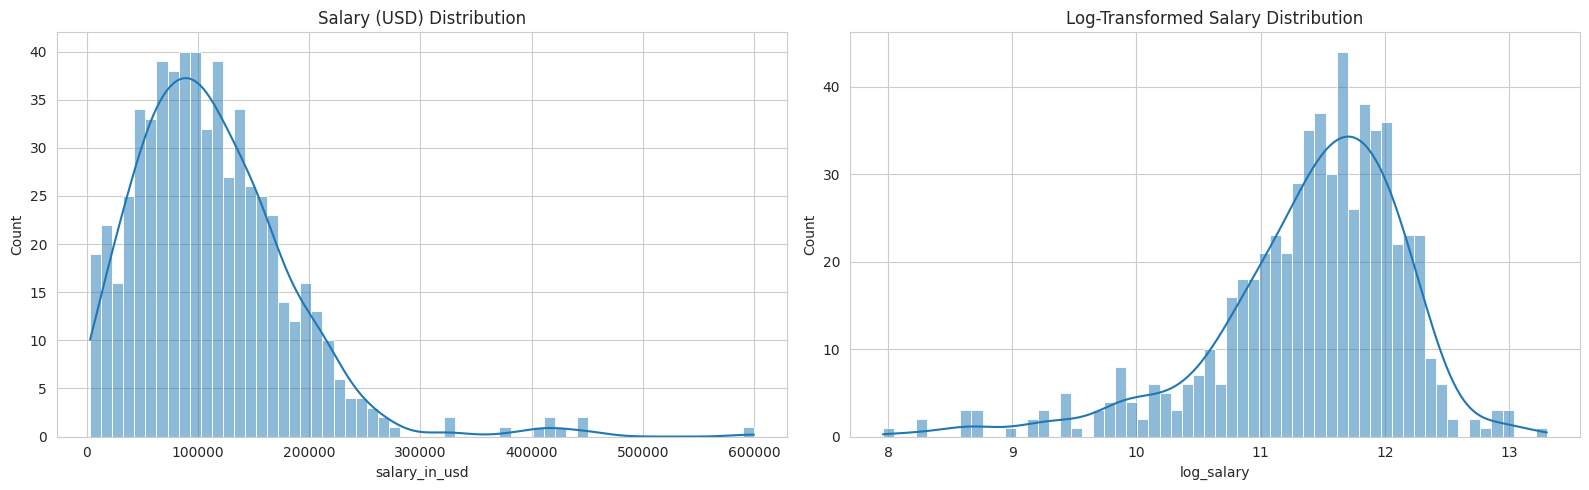

In [11]:
# Salary distribution (raw and log)
fig, axes = plt.subplots(1, 2, figsize=(16,5))

sns.histplot(df['salary_in_usd'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Salary (USD) Distribution')

df['log_salary'] = np.log1p(df['salary_in_usd'])
sns.histplot(df['log_salary'], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Salary Distribution')

plt.tight_layout()
plt.show()

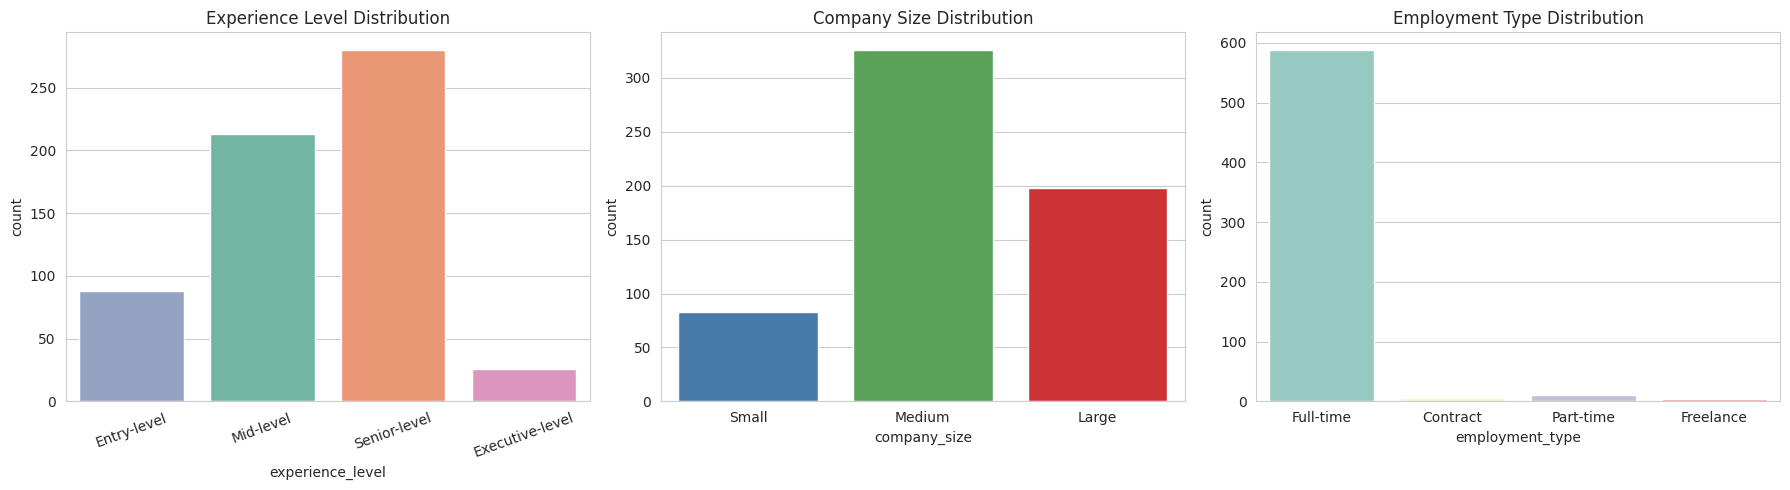

In [12]:
# Experience level, company size, employment type distributions
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(data=df, x='experience_level', hue='experience_level', palette='Set2', legend=False,
              order=['Entry-level','Mid-level','Senior-level','Executive-level'], ax=axes[0])
axes[0].set_title('Experience Level Distribution')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x='company_size', hue='company_size', palette='Set1', legend=False,
              order=['Small','Medium','Large'], ax=axes[1])
axes[1].set_title('Company Size Distribution')

sns.countplot(data=df, x='employment_type', hue='employment_type', palette='Set3', legend=False, ax=axes[2])
axes[2].set_title('Employment Type Distribution')

plt.tight_layout()
plt.show()

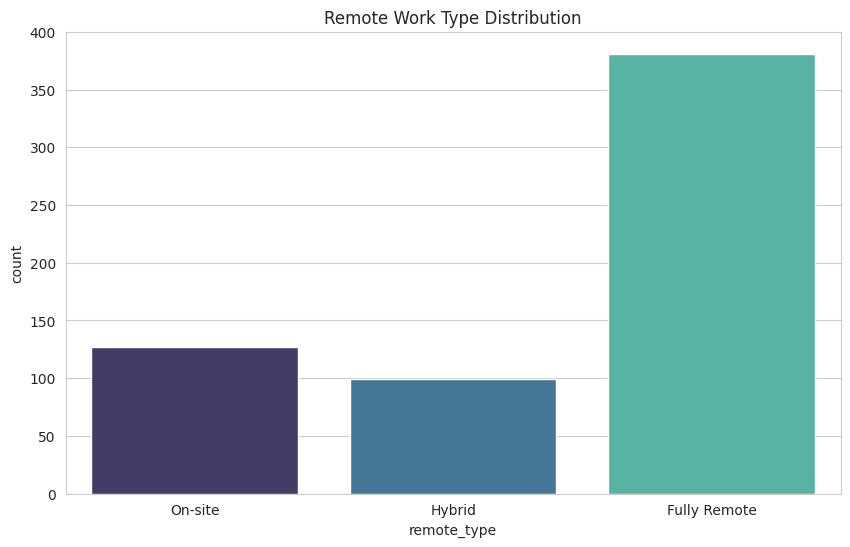

In [13]:
# Remote ratio distribution
sns.countplot(data=df, x='remote_type', hue='remote_type', palette='mako', legend=False,
              order=['On-site','Hybrid','Fully Remote'])
plt.title('Remote Work Type Distribution')
plt.show()

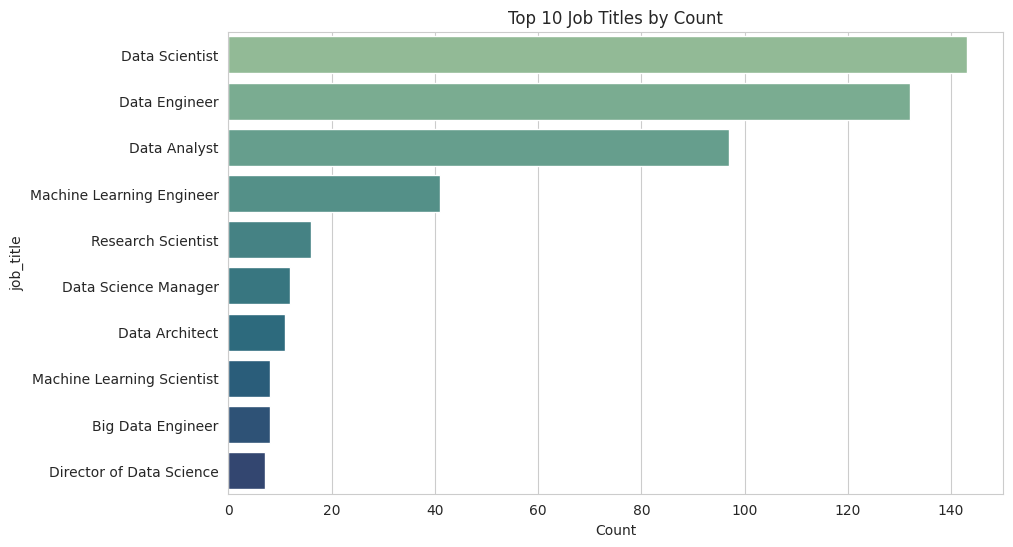

In [14]:
# Top 10 job titles by count
top_titles = df['job_title'].value_counts().head(10)

sns.barplot(x=top_titles.values, y=top_titles.index, hue=top_titles.index, palette='crest', legend=False)
plt.title('Top 10 Job Titles by Count')
plt.xlabel('Count')
plt.show()

**4. Salary Comparison Analysis**

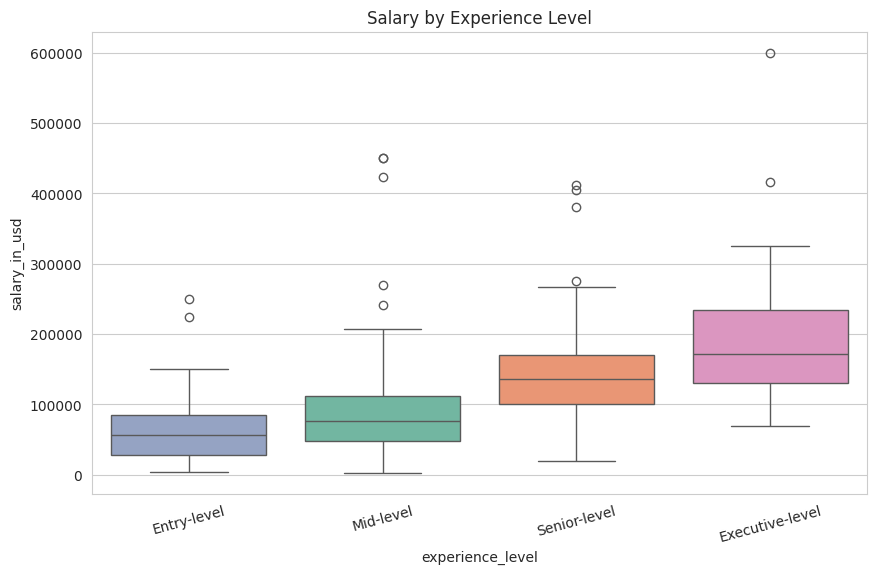

In [15]:
# Salary by experience level
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', hue='experience_level', palette='Set2', legend=False,
            order=['Entry-level','Mid-level','Senior-level','Executive-level'])
plt.title('Salary by Experience Level')
plt.xticks(rotation=15)
plt.show()

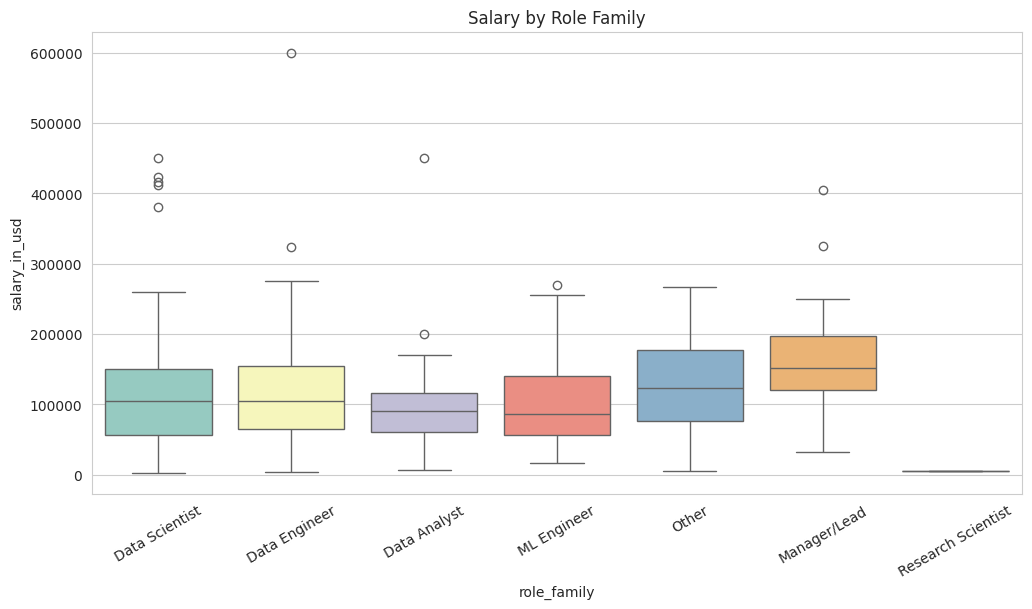

In [16]:
# Salary by role family
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='role_family', y='salary_in_usd', hue='role_family', palette='Set3', legend=False)
plt.title('Salary by Role Family')
plt.xticks(rotation=30)
plt.show()

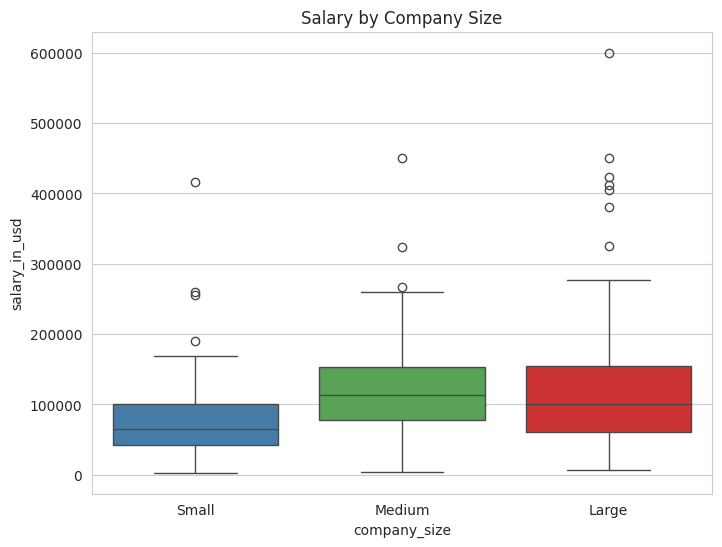

In [17]:
# Salary by company size
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='company_size', y='salary_in_usd', hue='company_size', palette='Set1', legend=False,
            order=['Small','Medium','Large'])
plt.title('Salary by Company Size')
plt.show()

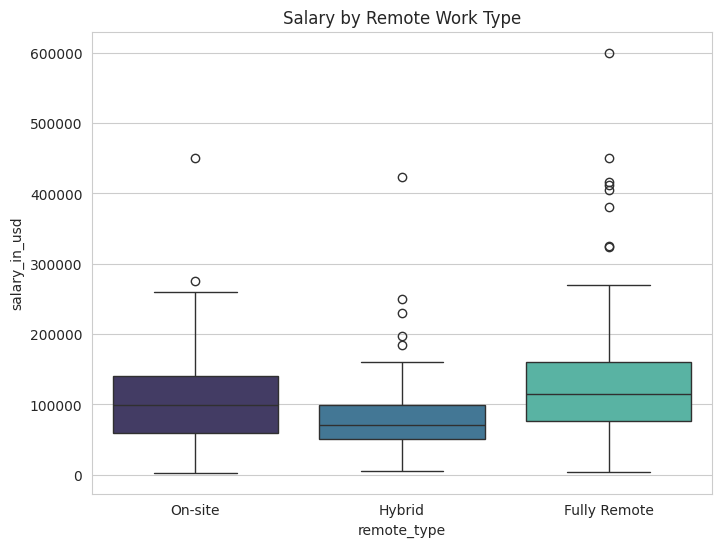

In [18]:
# Salary by remote type
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='remote_type', y='salary_in_usd', hue='remote_type', palette='mako', legend=False,
            order=['On-site','Hybrid','Fully Remote'])
plt.title('Salary by Remote Work Type')
plt.show()

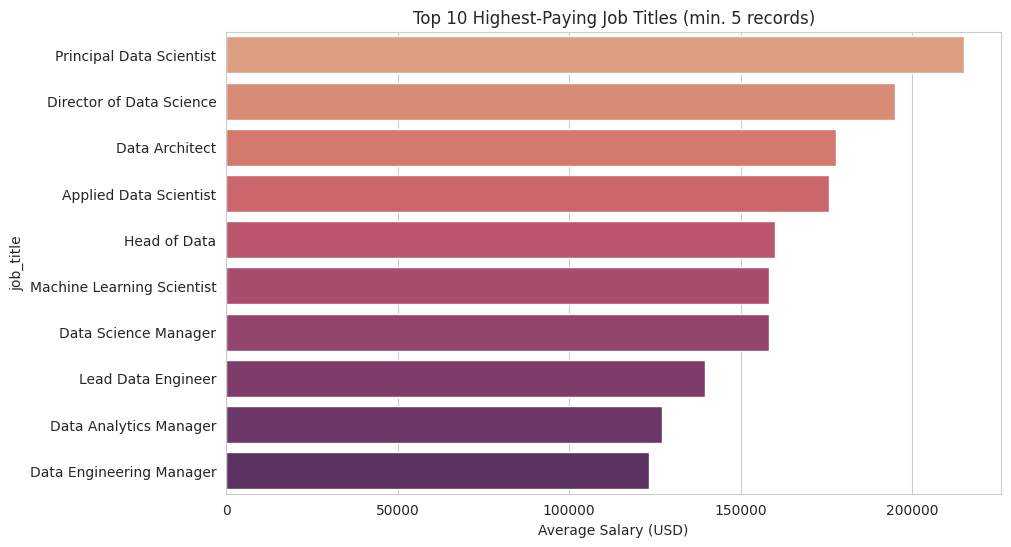

In [19]:
# Top 10 highest-paying job titles (min 5 records to avoid single-outlier skew)
title_counts = df['job_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index

avg_salary_by_title = df[df['job_title'].isin(valid_titles)].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=avg_salary_by_title.values, y=avg_salary_by_title.index, hue=avg_salary_by_title.index, palette='flare', legend=False)
plt.title('Top 10 Highest-Paying Job Titles (min. 5 records)')
plt.xlabel('Average Salary (USD)')
plt.show()

**5. Multivariate / Geographic Analysis**

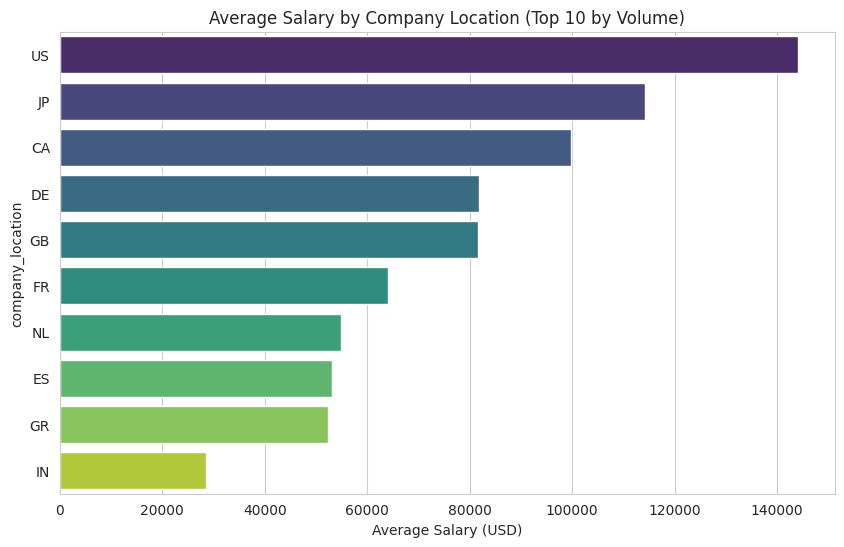

In [20]:
# Salary by top 10 company locations
top_locations = df['company_location'].value_counts().head(10).index
location_salary = df[df['company_location'].isin(top_locations)].groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False)

sns.barplot(x=location_salary.values, y=location_salary.index, hue=location_salary.index, palette='viridis', legend=False)
plt.title('Average Salary by Company Location (Top 10 by Volume)')
plt.xlabel('Average Salary (USD)')
plt.show()

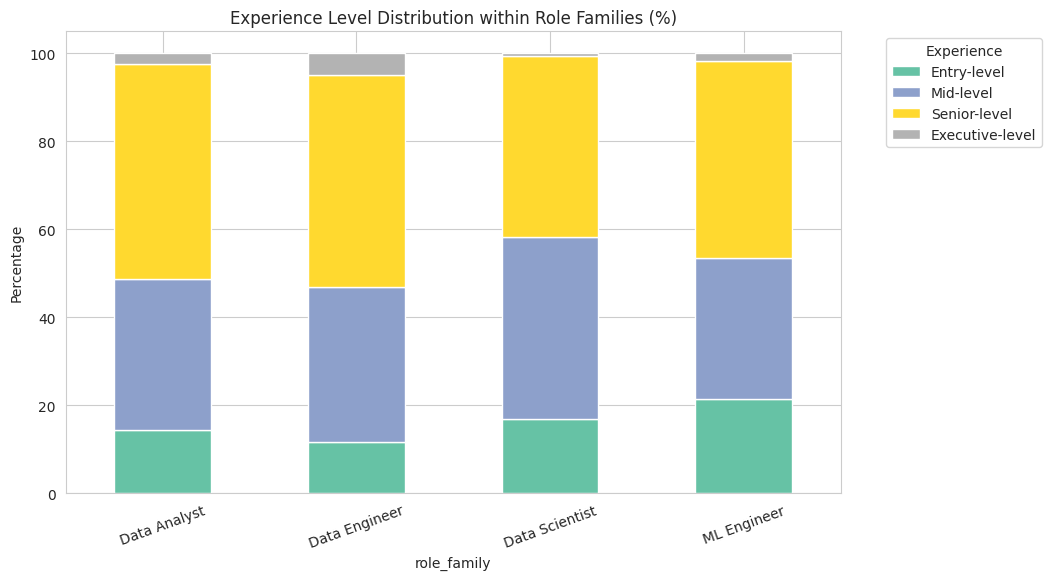

In [21]:
# Experience level distribution within top role families
top_roles = ['Data Scientist', 'Data Engineer', 'Data Analyst', 'ML Engineer']
role_exp = pd.crosstab(df[df['role_family'].isin(top_roles)]['role_family'],
                         df[df['role_family'].isin(top_roles)]['experience_level'], normalize='index') * 100
role_exp = role_exp[['Entry-level','Mid-level','Senior-level','Executive-level']]

role_exp.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Experience Level Distribution within Role Families (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=20)
plt.legend(title='Experience', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

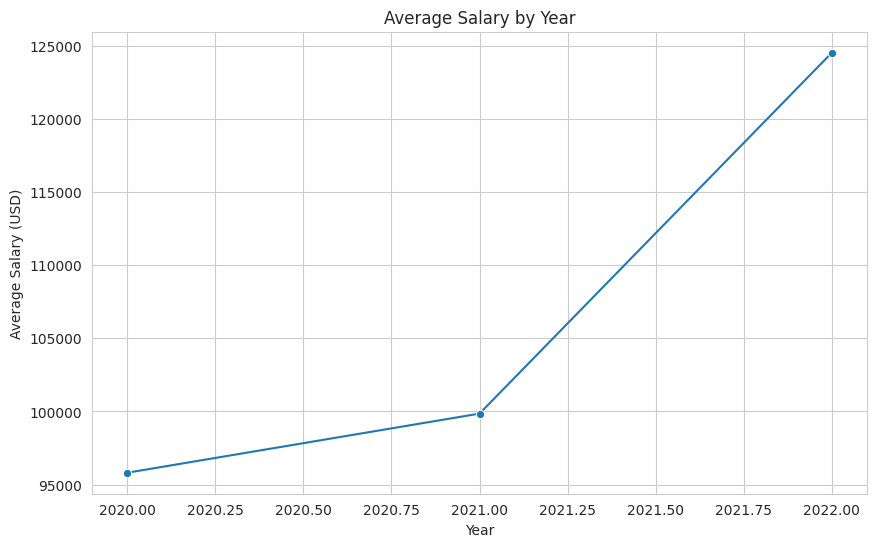

In [22]:
# Year-over-year average salary trend
if df['work_year'].nunique() > 1:
    yearly_salary = df.groupby('work_year')['salary_in_usd'].mean()

    plt.figure(figsize=(10,6))
    sns.lineplot(x=yearly_salary.index, y=yearly_salary.values, marker='o')
    plt.title('Average Salary by Year')
    plt.ylabel('Average Salary (USD)')
    plt.xlabel('Year')
    plt.show()
else:
    print("Only one year present in this dataset - skip trend analysis")

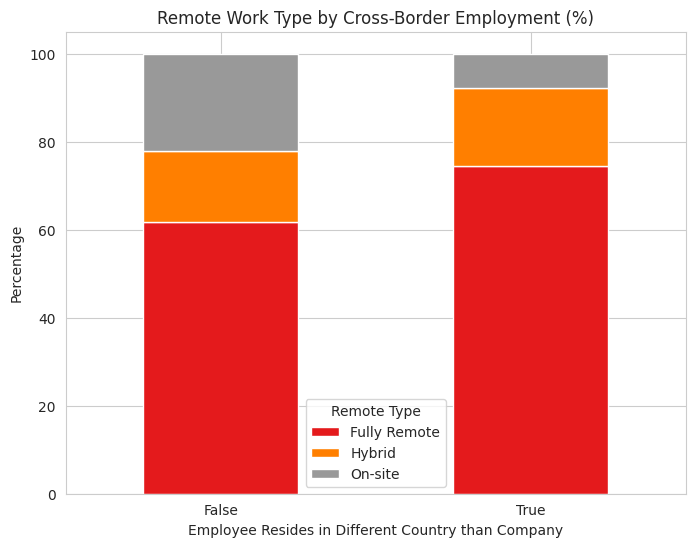

In [23]:
# Remote ratio vs whether employee resides in a different country than the company
df['different_country'] = df['employee_residence'] != df['company_location']

remote_vs_location = pd.crosstab(df['different_country'], df['remote_type'], normalize='index') * 100

remote_vs_location.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set1')
plt.title('Remote Work Type by Cross-Border Employment (%)')
plt.ylabel('Percentage')
plt.xlabel('Employee Resides in Different Country than Company')
plt.xticks(rotation=0)
plt.legend(title='Remote Type')
plt.show()

**6. Insights Summary + Series Wrap-Up**

## Key Insights

- Salary increases clearly with experience level, with Executive-level roles earning substantially more than Entry-level — the expected career-progression pattern holds strongly in this data.
- [Role family, e.g., ML Engineer or Data Scientist] commands the highest average salary among role families, while [role] trails behind.
- Large companies pay [higher/similar] salaries compared to small companies, suggesting [company resources / scale] plays a role in compensation.
- Fully remote roles [pay more/less/about the same] as on-site roles — [add your specific observation].
- [Country] offers the highest average salaries among top company locations by volume, likely reflecting cost-of-living and market differences.
- Cross-border employment (employee residing in a different country than the company) is strongly associated with [remote/hybrid] work arrangements, as expected.
- [Add 1-2 more insights specific to what you observed]

## Series Wrap-Up

This closes out a 15-project EDA series covering a wide range of data types and analytical techniques:

- **Categorical & text-heavy data** (Netflix, Amazon Reviews, YouTube Trending)
- **Numeric & geospatial analysis** (Airbnb NYC, California Housing, Chicago/Boston Crime)
- **Time series & seasonality** (Superstore Sales, Weather/Climate)
- **Statistical class comparison** (Heart Disease)
- **ML-readiness for classification & regression** (Telco Churn, California Housing)
- **Domain-specific feature analysis** (Spotify Audio Features, FIFA Player Attributes)
- **Cross-country panel data** (World Happiness Report)
- **Customer segmentation / RFM** (Online Retail)
- **Survey & compensation analysis** (Data Science Salaries)

Together, these projects demonstrate the ability to clean messy real-world data, choose the right visualization for different data types, and translate findings into actionable insights across business, health, civic, environmental, and consumer domains.